<a href="https://colab.research.google.com/github/bna14/Data-Driven_Modeling/blob/Assignments/EECE798K_Assignmnet_1_Problem_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [27]:
data_x = pd.read_csv('p2_x.txt',header=None,sep="  ")
data_y = pd.read_csv('p2_y.txt',header=None,sep="  ")
print(len(data_x.shape))

2


<ipython-input-27-0f34620b7423>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data_x = pd.read_csv('p2_x.txt',header=None,sep="  ")
<ipython-input-27-0f34620b7423>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data_y = pd.read_csv('p2_y.txt',header=None,sep="  ")


In [42]:
X_train, X_test, y_train, y_test = train_test_split(data_x,data_y,train_size=0.8,test_size=0.2)

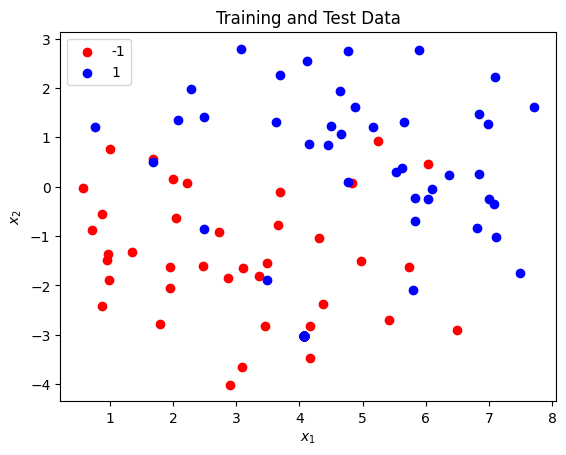

In [44]:
X_train, y_train = map(np.array, [X_train, y_train])

# Define colors and markers
colors = {1: 'blue', -1: 'red'}

# Plot training data
for label in [-1, 1]:
    idx = np.where(y_train == label)
    plt.scatter(X_train[idx, 0], X_train[idx, 1],
                c=colors[label],
                label=f'{label}')

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend()
plt.title("Training and Test Data")
plt.show()

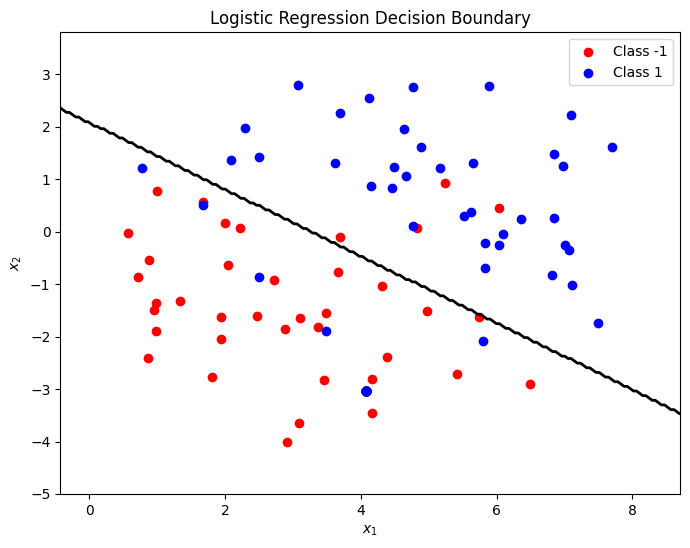

In [49]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train.ravel())
# Plot training data
plt.figure(figsize=(8,6))

colors = {1: 'blue', -1: 'red'}
for label in [-1, 1]:
    idx = np.where(y_train == label)
    plt.scatter(X_train[idx, 0], X_train[idx, 1], c=colors[label], label=f"Class {label}")

# Plot decision boundary
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])  # Predict on grid points
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')  # Decision boundary

# Labels and legend
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend()
plt.title("Logistic Regression Decision Boundary")
plt.show()

In [51]:
model_score = model.score(X_test,y_test)
print(f"{model_score = }")

model_score = 0.95


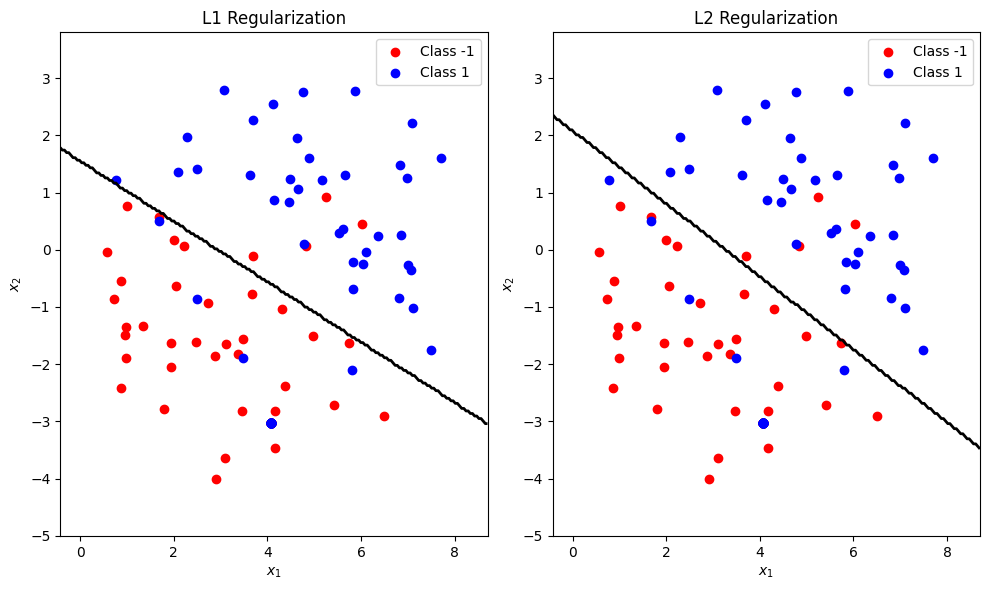

In [63]:
l1_model = LogisticRegression(penalty='l1', solver='liblinear')
l2_model = LogisticRegression(penalty='l2')

# Fit models
l1_model.fit(X_train, y_train.ravel())
l2_model.fit(X_train, y_train.ravel())

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Define colors
colors = {1: 'blue', -1: 'red'}

# Decision boundary function
def plot_decision_boundary(ax, model, title):
    for label in [-1, 1]:
        idx = np.where(y_train == label)
        ax.scatter(X_train[idx, 0], X_train[idx, 1], c=colors[label], label=f"Class {label}")

    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
    ax.legend()

# Plot L1 model
plot_decision_boundary(axes[0], l1_model, "L1 Regularization")

# Plot L2 model
plot_decision_boundary(axes[1], l2_model, "L2 Regularization")

# Adjust layout and show plots
plt.tight_layout()
plt.show()


In [64]:
model_l1_score = l1_model.score(X_test,y_test)
model_l2_score = l2_model.score(X_test,y_test)
print(f"{model_l1_score = }")
print(f"{model_l2_score = }")

model_l1_score = 0.9
model_l2_score = 0.95
